In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import pwlf
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages

from scipy.optimize import curve_fit


In [2]:
analyse = AnalysisFunc()
reader = DataRead()
algo = UmapAlgo()
algo_pf = AlgoParFull()
comm_partcptn = CommPercentages()

### Read ST and FPT data from results
- This data from older simulations for which there is no NC data
- Change this analysis data once you fine fit it

In [5]:
params = reader.data_read_pkl(f'results/calculate_final_params/final_fn.pkl')

In [5]:
params[1].keys()
# 1 for partial
# 2 for full


dict_keys(['t_t', 'fp_t', 's_t', 'cov'])

In [6]:
part_fpt=params[1]["fp_t"]
part_fpt=[x for x in part_fpt if x>25 and x<1000]
full_fpt=params[2]["fp_t"]  
full_fpt=[x for x in full_fpt if x>25 and x<1000]

full_st=params[2]["s_t"]
full_st=[x for x in full_st if x>25 and x<1000]
part_st=params[1]["s_t"]
part_st=[x for x in part_st if x>25 and x<1000]

In [7]:
min(full_fpt)

30.0

In [ ]:
full_st

#### Explaination behind fitting CCDF
Sort intervals → put waiting times in order.
Compute CCDF → probability of waiting longer than each time.
Take log → so exponential becomes linear.
Fit a line → slope ≈ λ
Plot points + line → check visually if it’s straight.
Return λ → estimated rate of arrivals.
Imagine you’re waiting for ice cream 🍦. Sometimes you wait 2 minutes, sometimes 5 minutes, sometimes 10 minutes. You write down all the waiting times.
Now, if the ice cream man comes randomly (like rolling dice), the times you wait should follow a special "random waiting pattern" called exponential distribution.
How do we check?
We line up all the waiting times from smallest to biggest.
We ask: “What’s the chance I wait longer than this time?” (that’s the CCDF: probability of waiting more than t).
If we draw this chance on a special graph (logarithmic scale), exponential waiting times make a straight line.
If it’s straight, we say: “Yes! My waiting times are exponential.”
The slope of that line tells us how fast the ice cream man usually comes (that’s λ, the rate).

In [3]:
def expo_plot_two_lines(intervals, ax, label, split_index=None):
    # Sort data
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    # Default split: halfway
    if split_index is None:
        split_index = len(intervals) // 2

    # First segment fit
    slope1, intercept1 = np.polyfit(intervals[:split_index], log_ccdf[:split_index], 1)
    lam1 = -slope1

    # Second segment fit
    slope2, intercept2 = np.polyfit(intervals[split_index:], log_ccdf[split_index:], 1)
    lam2 = -slope2

    # Plot scatter
    ax.scatter(intervals, log_ccdf, s=20, alpha=0.7, label=label)

    # Plot first line
    ax.plot(
        intervals[:split_index],
        slope1 * intervals[:split_index] + intercept1,
        'r-',
        label=f'Fit 1 (λ ≈ {lam1:.3f})'
    )

    # Plot second line
    ax.plot(
        intervals[split_index:],
        slope2 * intervals[split_index:] + intercept2,
        'g-',
        label=f'Fit 2 (λ ≈ {lam2:.3f})'
    )

    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF {label} (2 fits)")
    ax.legend()


[ 30.         820.62249407 965.        ]


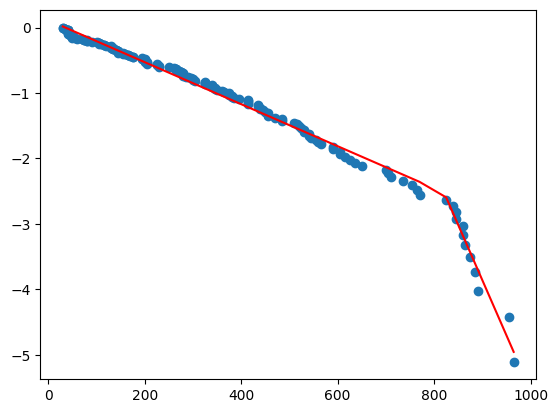

In [11]:
import pwlf
intervals=part_fpt.copy()
intervals = np.sort(intervals)
n = len(intervals)

# CCDF: P(T > t)
ccdf = 1.0 - np.arange(1, n + 1) / n

# Remove zero values (log undefined)
mask = ccdf > 0
intervals = intervals[mask]
ccdf = ccdf[mask]

# Log of CCDF
log_ccdf = np.log(ccdf)
# Fit piecewise linear with 3 segments
x=intervals
y=log_ccdf
my_pwlf = pwlf.PiecewiseLinFit(x, y)
breaks = my_pwlf.fit(2)

# Predict
y_hat = my_pwlf.predict(x)
print(breaks)
plt.scatter(x, y)
plt.plot(x, y_hat, 'r')
plt.show()


In [8]:
breaks[0]

30.0

In [4]:
def fit_piecewiseLinear(data,ax,label):
	intervals=data.copy()
	intervals = np.sort(intervals)
	n = len(intervals)

	# CCDF: P(T > t)
	ccdf = 1.0 - np.arange(1, n + 1) / n

	# Remove zero values (log undefined)
	mask = ccdf > 0
	intervals = intervals[mask]
	ccdf = ccdf[mask]

	# Log of CCDF
	log_ccdf = np.log(ccdf)
	# Fit piecewise linear with 3 segments
	x=intervals
	y=log_ccdf
	my_pwlf = pwlf.PiecewiseLinFit(x, y)
	breaks = my_pwlf.fit(2)

	# Predict
	y_hat = my_pwlf.predict(x)

	ax.scatter(x, y)
	ax.plot(x, y_hat, 'r')
	ax.set_ylabel("log P(T > t)")
	ax.set_title(f"Log-CCDF {label} {breaks} (2 fits)")
	ax.legend()
	

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


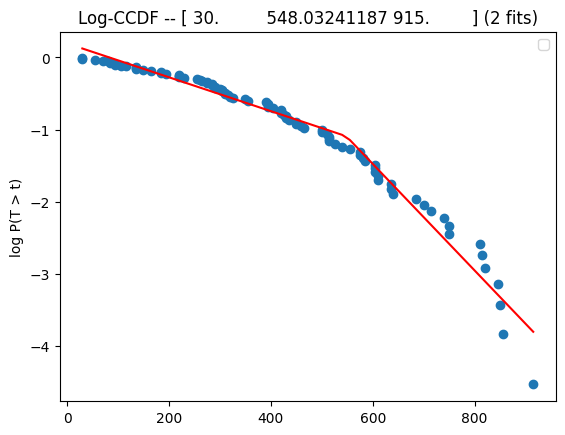

In [10]:
fit_piecewiseLinear(full_fpt, plt.gca(), "--")

## Get all data from folder

In [ ]:
#old data
# data_folder = Path('../../data/results/partial_full_data_200_itr/')
# files = list(data_folder.glob('*'))
# files = glob.glob(str(data_folder / "*.pkl"))
# params = reader.data_read_pkl(f'results/partial_full_data_200_itr/FN')

In [4]:
data_folder = Path('../../data/results/calculate_final_params')
files=list(data_folder.glob('*'))
print(files)

[WindowsPath('../../data/results/calculate_final_params/final_bla.pkl'), WindowsPath('../../data/results/calculate_final_params/final_enti.pkl'), WindowsPath('../../data/results/calculate_final_params/final_fn.pkl'), WindowsPath('../../data/results/calculate_final_params/final_lha.pkl'), WindowsPath('../../data/results/calculate_final_params/final_lsc.pkl'), WindowsPath('../../data/results/calculate_final_params/final_mob.pkl'), WindowsPath('../../data/results/calculate_final_params/final_mop.pkl'), WindowsPath('../../data/results/calculate_final_params/final_mos.pkl'), WindowsPath('../../data/results/calculate_final_params/final_mrn.pkl'), WindowsPath('../../data/results/calculate_final_params/final_orb.pkl'), WindowsPath('../../data/results/calculate_final_params/final_peri.pkl'), WindowsPath('../../data/results/calculate_final_params/final_pir.pkl'), WindowsPath('../../data/results/calculate_final_params/final_re.pkl')]


### To plot (saved in results folder)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing file: ..\..\data\results\calculate_final_params\final_mos.pkl
Processing file: ..\..\data\results\calculate_final_params\final_mrn.pkl
Processing file: ..\..\data\results\calculate_final_params\final_orb.pkl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Processing file: ..\..\data\results\calculate_final_params\final_peri.pkl
Processing file: ..\..\data\results\calculate_final_params\final_pir.pkl
Processing file: ..\..\data\results\calculate_final_params\final_re.pkl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


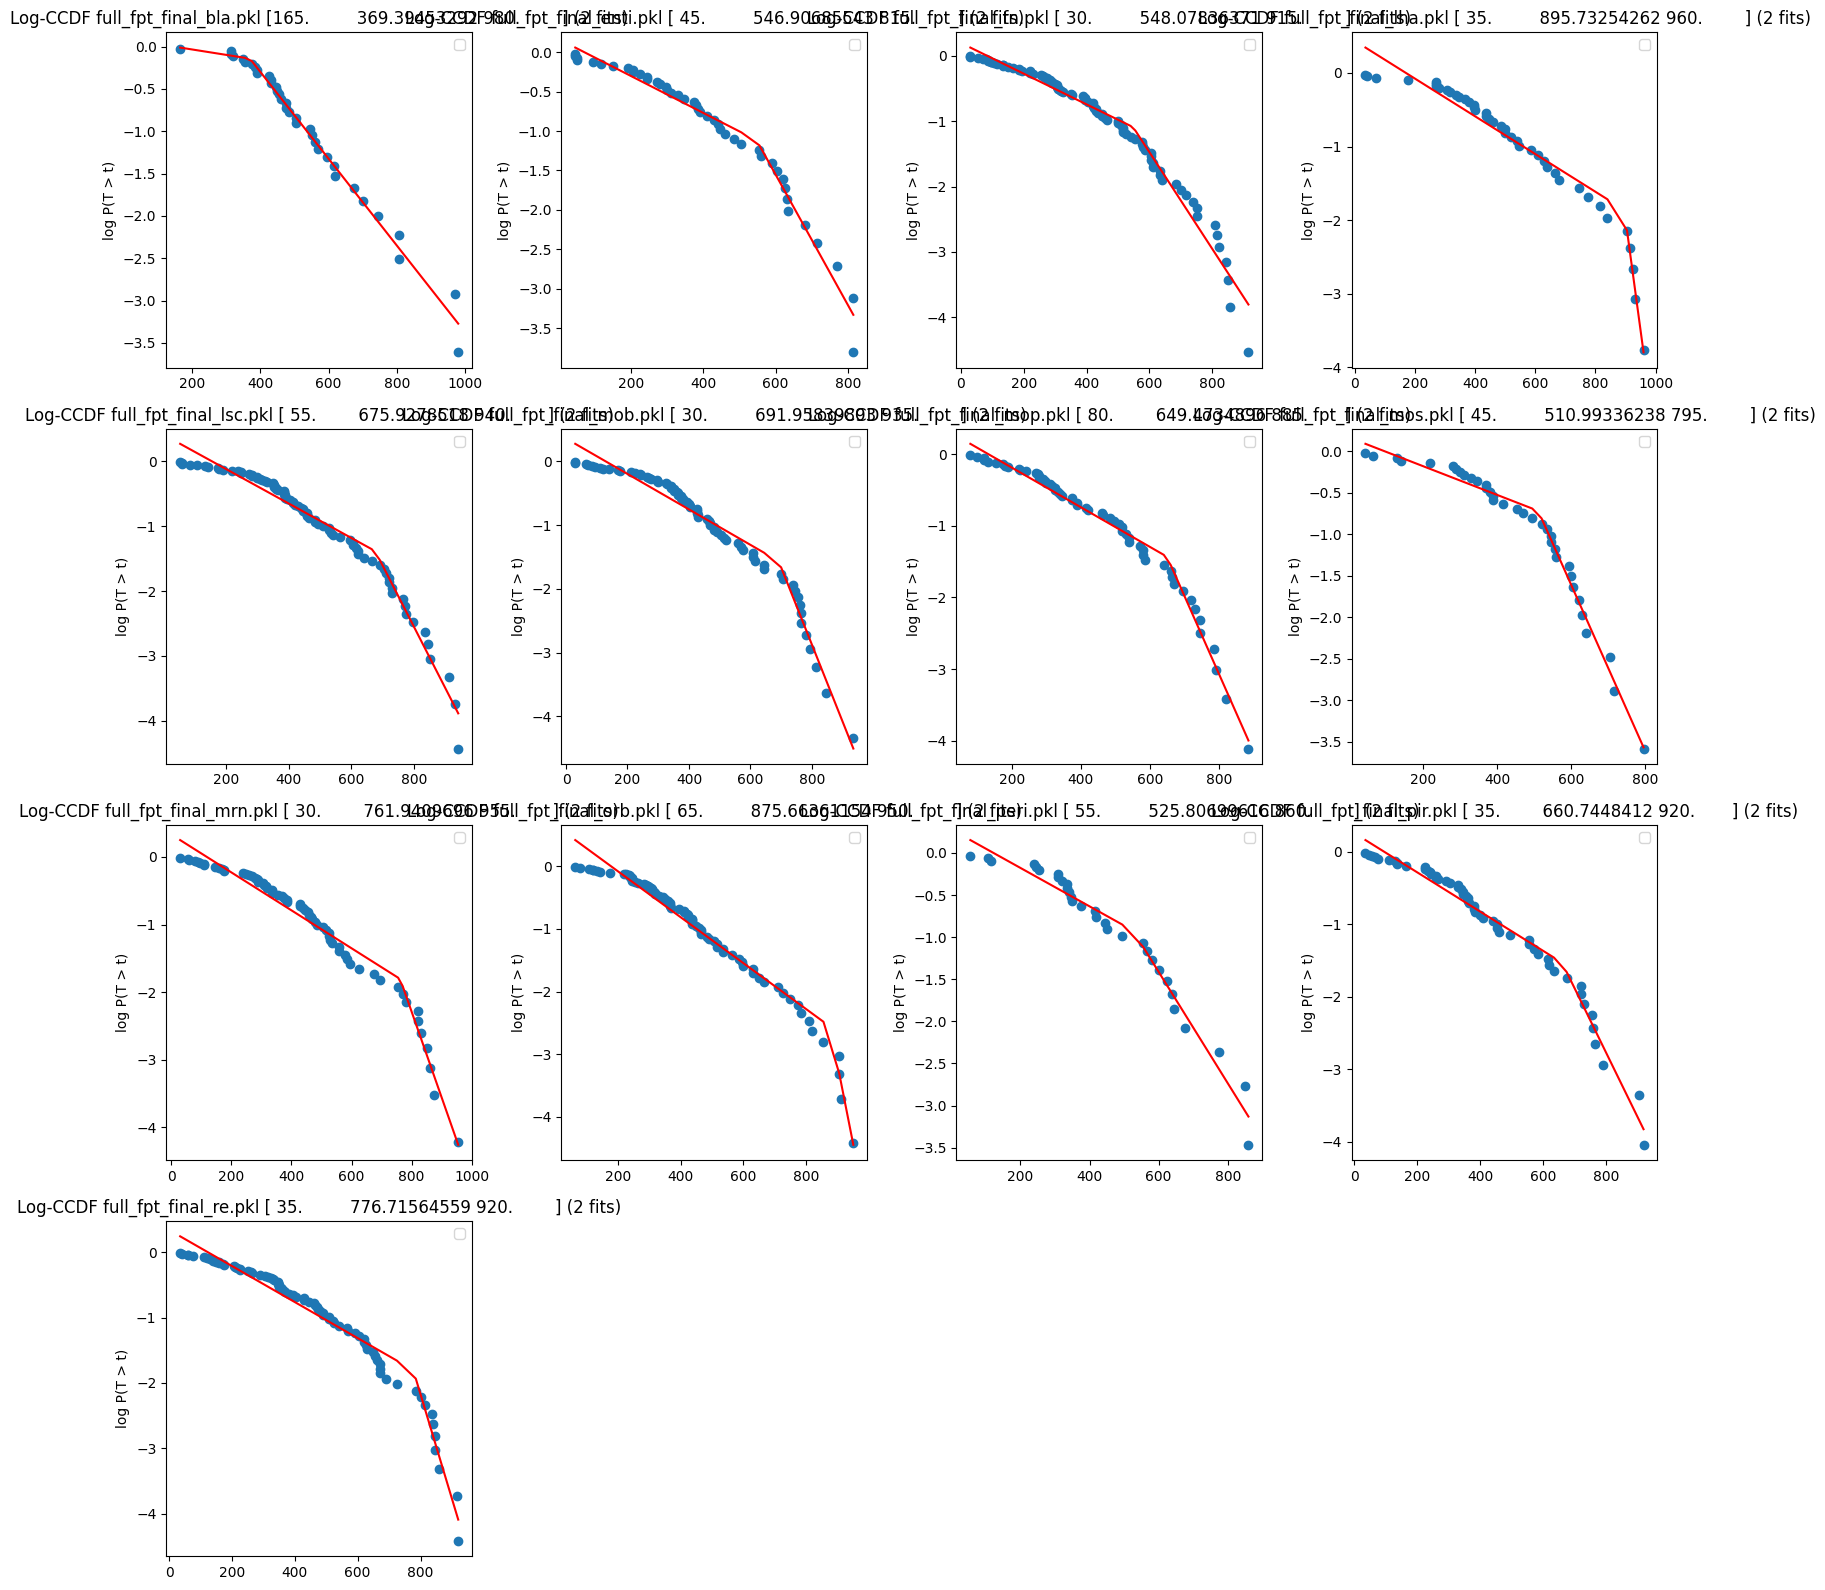

In [6]:
# to plot in grid
import matplotlib.pyplot as plt
import pickle

# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
    fname = Path(file).name
    if file != 'MRN':  # skip MRN in full st data by replacing file by fname
        with open(file, "rb") as f:
            params = pickle.load(f)

        part_fpt = [x for x in params[1]["fp_t"] if 25 < x < 1000]
        full_fpt = [x for x in params[2]["fp_t"] if 25 < x < 1000]

        full_st = [x for x in params[2]["s_t"] if 25 < x < 1000]
        part_st = [x for x in params[1]["s_t"] if 25 < x < 1000]

        fit_piecewiseLinear(full_fpt, ax, f'full_fpt_{file.name}')
    else:
        ax.axis("off")  # hide MRN plot

# Hide unused subplots if fewer than 16 files
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [ ]:
fig,axes = plt.subplots(len(files),1, figsize=(8,4*len(files)))
for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
    if file != 'MRN': # change file.name for full st as it's data does not fit

        with open(file, "rb") as f:
            params = pickle.load(f)

        part_fpt=params[1]["fp_t"]
        part_fpt=[x for x in part_fpt if x>25 and x<1000]
        full_fpt=params[2]["fp_t"]  
        full_fpt=[x for x in full_fpt if x>25 and x<1000]

        full_st=params[2]["s_t"]
        full_st=[x for x in full_st if x>25 and x<1000]
        part_st=params[1]["s_t"]
        part_st=[x for x in part_st if x>25 and x<1000]
        expo_plot_two_lines(part_st,ax,f'part_st_{file.name}')
    else:
        continue
  
plt.tight_layout()
plt.savefig('../../data/results/Part ST fit.pdf',format='pdf')



#### Returns line parameters with tolerances
- saved in results folder as csv files
- not done for ST data


In [36]:


def expo_plot_two_lines_params(intervals, label, split_index=None, save_path="../../data/results/fit_part_fpt_params.csv"):
    # Sort data
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    # Default split: halfway
    if split_index is None:
        split_index = len(intervals) // 2

    # First segment fit with covariance
    coeffs1, cov1 = np.polyfit(intervals[:split_index], log_ccdf[:split_index], 1, cov=True)
    slope1, intercept1 = coeffs1
    lam1 = -slope1
    slope1_err, intercept1_err = np.sqrt(np.diag(cov1))

    # Second segment fit with covariance
    coeffs2, cov2 = np.polyfit(intervals[split_index:], log_ccdf[split_index:], 1, cov=True)
    slope2, intercept2 = coeffs2
    lam2 = -slope2
    slope2_err, intercept2_err = np.sqrt(np.diag(cov2))

    # # Plot scatter
    # ax.scatter(intervals, log_ccdf, s=20, alpha=0.7, label=label)

    # # Plot first line
    # ax.plot(
    #     intervals[:split_index],
    #     slope1 * intervals[:split_index] + intercept1,
    #     'r-',
    #     label=f'Fit 1 (λ ≈ {lam1:.3f})'
    # )

    # # Plot second line
    # ax.plot(
    #     intervals[split_index:],
    #     slope2 * intervals[split_index:] + intercept2,
    #     'g-',
    #     label=f'Fit 2 (λ ≈ {lam2:.3f})'
    # )

    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} (2 fits)")
    # ax.legend()

    # Threshold: the first interval where second fit starts
    threshold = intervals[split_index]

    # Collect parameters
    params = {
        "label": label,
        "slope1": slope1, "slope1_err": slope1_err,
        "intercept1": intercept1, "intercept1_err": intercept1_err,
        "lambda1": lam1,
        "slope2": slope2, "slope2_err": slope2_err,
        "intercept2": intercept2, "intercept2_err": intercept2_err,
        "lambda2": lam2,
        "threshold": threshold
    }

    # --- Save to CSV ---
    save_file = Path(save_path)
    df_new = pd.DataFrame([params])

    if save_file.exists():
        df_old = pd.read_csv(save_file)
        df_all = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(save_file, index=False)

    return params


### Change variable names and path accordingly

In [41]:
for file in  files:
    print(f'Processing file: {file}')
    if file != 'MRN': # change file.name for full st as it's data does not fit

        with open(file, "rb") as f:
            params = pickle.load(f)

        part_fpt=params[1]["fp_t"]
        part_fpt=[x for x in part_fpt if x>25 and x<1000]
        full_fpt=params[2]["fp_t"]  
        full_fpt=[x for x in full_fpt if x>25 and x<1000]

        full_st=params[2]["s_t"]
        full_st=[x for x in full_st if x>25 and x<1000]
        part_st=params[1]["s_t"]
        part_st=[x for x in part_st if x>25 and x<1000]
        print(expo_plot_two_lines_params(part_st,f'part_st_{file.name}',save_path="../../data/results/fit_part_st_params.csv"))
    else:
        continue

Processing file: ..\..\data\results\partial_full_data_200_itr\BLA
{'label': 'part_st_BLA', 'slope1': -0.01718390422933848, 'slope1_err': 0.0005727999937687654, 'intercept1': 0.9614820810378161, 'intercept1_err': 0.042880758973463357, 'lambda1': 0.01718390422933848, 'slope2': -0.010969521594553769, 'slope2_err': 0.00027822195940810704, 'intercept2': 0.20188311766727657, 'intercept2_err': 0.05143436886271634, 'lambda2': 0.010969521594553769, 'threshold': 100.0}
Processing file: ..\..\data\results\partial_full_data_200_itr\ENTI
{'label': 'part_st_ENTI', 'slope1': -0.02373968603499844, 'slope1_err': 0.000572868596626835, 'intercept1': 1.3791549686963482, 'intercept1_err': 0.04093355581389495, 'lambda1': 0.02373968603499844, 'slope2': -0.00820323367269393, 'slope2_err': 0.0001960093015464176, 'intercept2': -0.13048225851127526, 'intercept2_err': 0.042198940812149775, 'lambda2': 0.00820323367269393, 'threshold': 90.0}
Processing file: ..\..\data\results\partial_full_data_200_itr\FN
{'label':